## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage, plot_uv_coverage_2


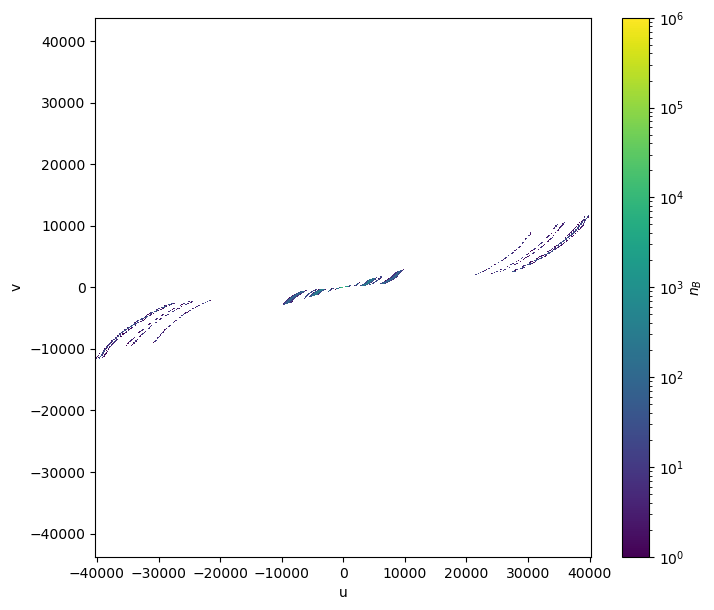

In [4]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/ska_low_AA2.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T03:00:00",
    "utc_end": "2023-11-21T05:00:00",
    "step_min": 2,
    "n_freqs": 1500,
    'bandwidth': None, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 1,
    "max_offset_deg": 1.0, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ , times_sec = visibilities_simulation(SKA_LOW_AA1)

# plot_uv_coverage(uvw, unit='km')
plot_uv_coverage_2(uvw, 512)

In [5]:
print("uvw shape: ", uvw.shape)
print("V shape: ", V.shape)
print("V baselines shape: ", V[0].shape)
print("Primeros 3 registros del baseline 0: \n", V[0][:3])   

uvw shape:  (2016, 61, 3)
V shape:  (2016, 61, 1500)
V baselines shape:  (61, 1500)
Primeros 3 registros del baseline 0: 
 [[ 1.6258492 +0.51752555j  1.6252096 +0.51953065j  1.6245675 +0.5215349j
  ... -0.9406514 +1.4235144j  -0.9424066 +1.422353j
  -0.9441604 +1.4211894j ]
 [ 1.6244026 +0.5220483j   1.6237516 +0.52406967j  1.6230981 +0.52609026j
  ... -0.9681715 +1.4049422j  -0.9699194 +1.403736j
  -0.97166574+1.4025277j ]
 [ 1.6229582 +0.5265217j   1.6222957 +0.52855915j  1.6216308 +0.5305958j
  ... -0.9950543 +1.3860322j  -0.9967939 +1.3847816j
  -0.99853194+1.383529j  ]]


Inyección de RFI

In [6]:
from modules.noise import narrowband_rfi, broadband_rfi, transient_rfi

V_rfi, k, f_rfi = narrowband_rfi(
    V,
    frequencies,
    amplitude=(0, 10),
    k_rfi=[10, 90, 175, 210, 97, 14, 15, 26, 431, 708, 900],
    duty_cycle=0.6,
)


V_rfi_bb, k_bb, f_rfi_bb = broadband_rfi(
    V,
    frequencies,
    amplitude=(0, 10),
    k_range=(300,378),
    duty_cycle=0.5
)

V_rfi_t, k_t = transient_rfi(
    V,
    times=times_sec,
    amplitude=10,
    n_step=[10, 50, 75],
    duration_steps=1,
    # t_rfi=3600
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted = V + V_rfi + V_rfi_bb + V_rfi_t

Canal RFI: [ 10  90 175 210  97  14  15  26 431 708 900]
Frecuencia [MHz]: [ 52.00133422  68.01200801  85.0233489   92.02801868  69.41294196
  52.80186791  53.00200133  55.20346898 136.257505   191.69446298
 230.12008005]


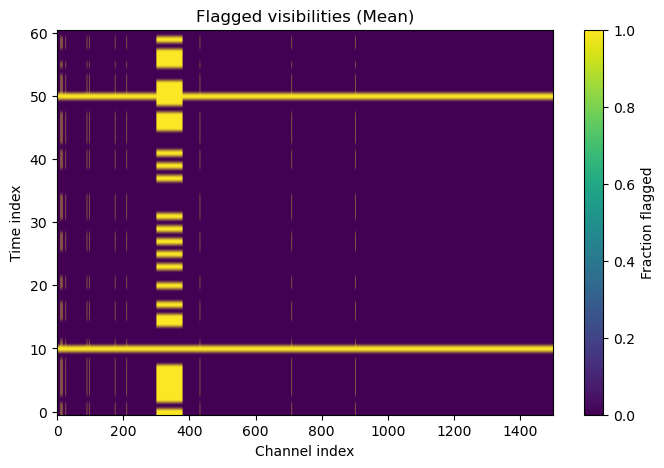

In [50]:
from modules.plots import plot_flag_map

true_mask = np.abs(V_rfi + V_rfi_bb + V_rfi_t) > 0
plot_flag_map(true_mask, mode='mean')

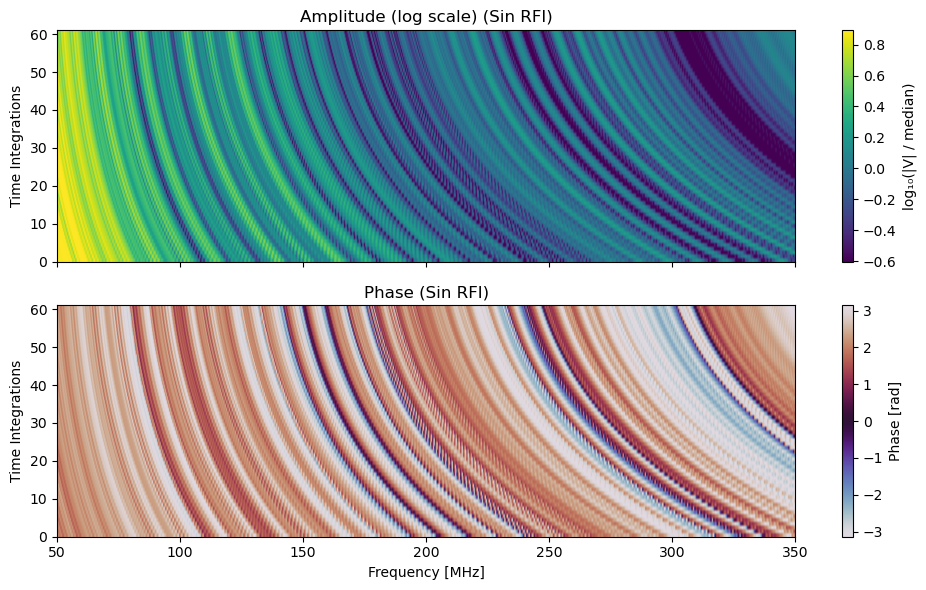

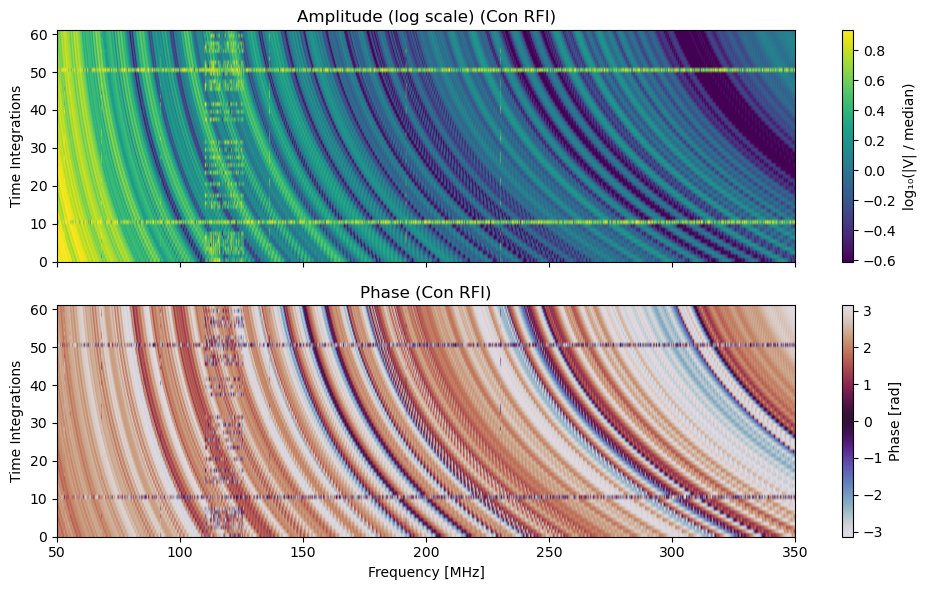

In [8]:
from modules.plots import plot_time_frequency

plot_time_frequency(
    V,
    frequencies,
    title_suffix="(Sin RFI)"
)

plot_time_frequency(
    V_corrupted,
    frequencies,
    title_suffix="(Con RFI)"
)

### Estadísticas de contaminación

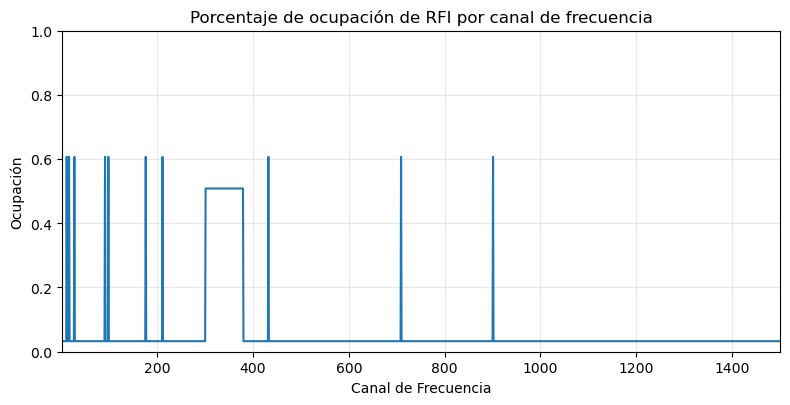

In [71]:
from modules.flagging import frequency_occupancy, mad, spectral_kurtosis

frequency_occ = frequency_occupancy(true_mask)
channels = np.arange(1, 1501)

plt.figure(figsize=(8, 4))
plt.plot(channels, frequency_occ, lw=1.5)

plt.xlabel("Canal de Frecuencia")
plt.ylabel("Ocupación")
plt.ylim(0, 1)
plt.xlim(1, 1500)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.title("Porcentaje de ocupación de RFI por canal de frecuencia")
plt.show()

In [64]:
MAD = mad(V_corrupted)

1.1920929e-07 6.3456097


Text(0.5, 1.0, 'Métrica MAD por canal de frecuencia')

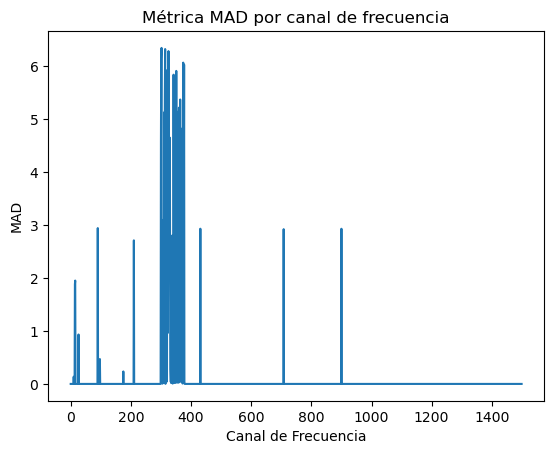

In [70]:
print(MAD.min(), MAD.max())

plt.plot(MAD)
plt.xlabel("Canal de Frecuencia")
plt.ylabel("MAD")
plt.title("Métrica MAD por canal de frecuencia")

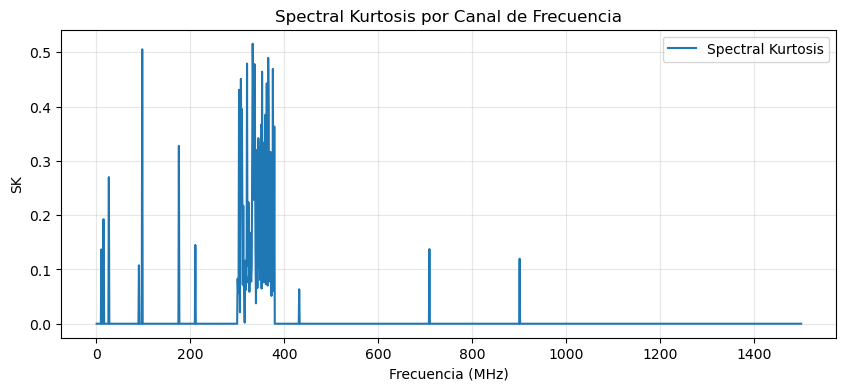

In [79]:
sk = spectral_kurtosis(V_corrupted)

plt.figure(figsize=(10, 4))
    
    # Graficamos la SK para un baseline
plt.plot(channels, sk[0, :], label='Spectral Kurtosis')


plt.title("Spectral Kurtosis por Canal de Frecuencia")
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("SK")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Ejercicio de programación 4 - Algortimos de Flagging

1. Implementar algoritmo SumThreshold adaptado para coordenadas UVW
2. Implementar flagging por umbral estadistico
3. Implementar flagging por variacion de amplitud
4. Implementar flagging por coherencia de fase
5. Combinar diferentes algoritmos de flagging
6. Evaluar rendimiento con metricas de precision, recall y F1
7. Visualizar resultados de flagging en el plano UV


### 1. SumTreshold

In [9]:
from modules.flagging import sumthreshold_frequency, calculate_rfi_metrics

flags_st = sumthreshold_frequency(V_corrupted, k=3, window_sizes=(1,2))

In [11]:
# mask
V_flagged_st = V_corrupted.copy()

V_flagged_st[flags_st] = np.nan

print("Fracción de datos flaggeados:",
      flags_st.mean())

Fracción de datos flaggeados: 0.5253850507416081


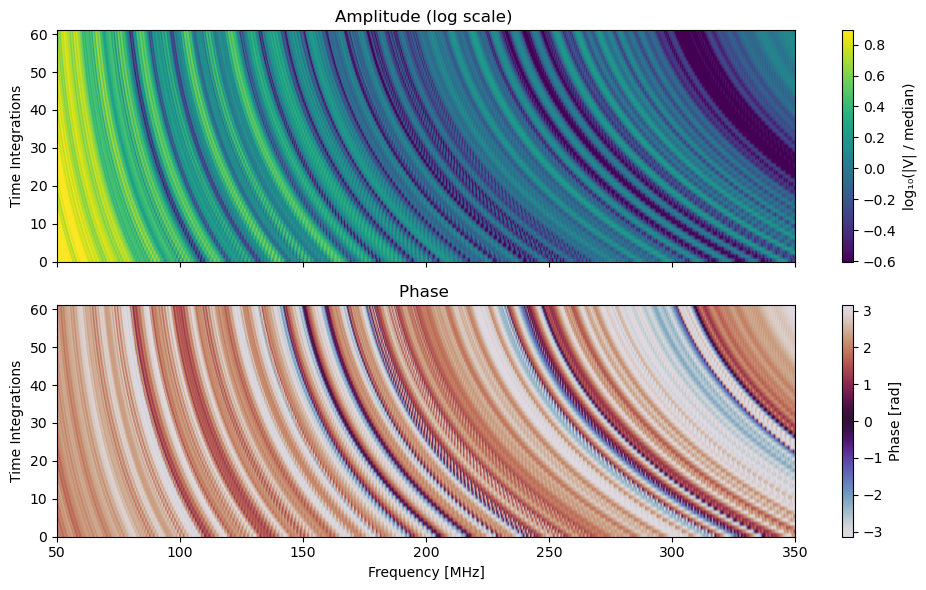

In [12]:
plot_time_frequency(V, frequencies)

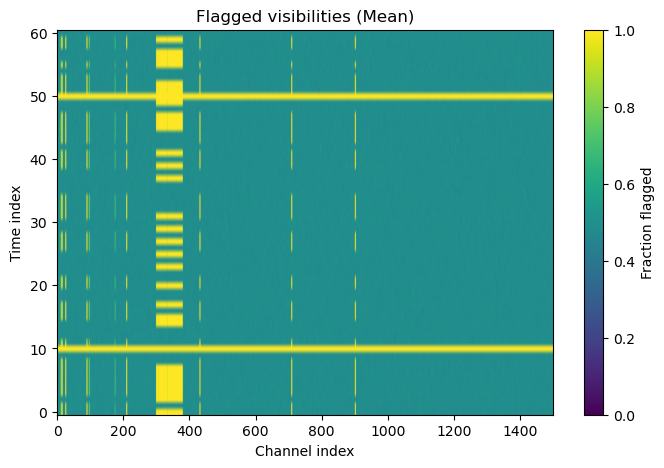

In [13]:
from modules.plots import plot_flag_map

plot_flag_map(flags_st, mode='mean')

In [14]:
calculate_rfi_metrics(predicted_mask=flags_st, true_mask=true_mask)

{'Precision': np.float64(0.11708919730879017),
 'Recall': np.float64(0.9916838652303769),
 'F1-Score': np.float64(0.20944857281794135),
 'TP': np.int64(11347656),
 'FP': np.int64(85566972),
 'FN': np.int64(95160)}

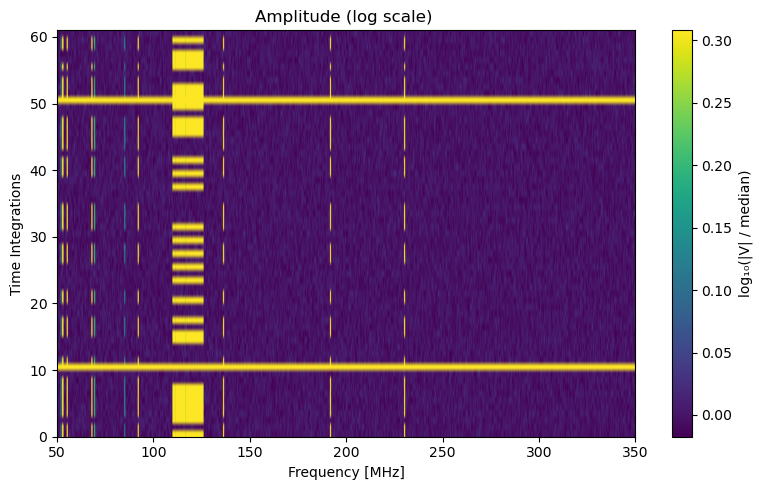

In [15]:
plot_time_frequency(V=flags_st, frequencies=frequencies, show_phase=False, figsize=(8,5))

## 2. Umbral estadístico

In [16]:
from modules.flagging import statistical_threshold

flags_stat = statistical_threshold(V_corrupted, k=1)

In [17]:
# mask
V_flagged_stat = V_corrupted.copy()
V_flagged_stat[flags_stat] = np.nan

print("Fracción de datos flaggeados:",
      flags_stat.mean())

Fracción de datos flaggeados: 0.042532369459623555


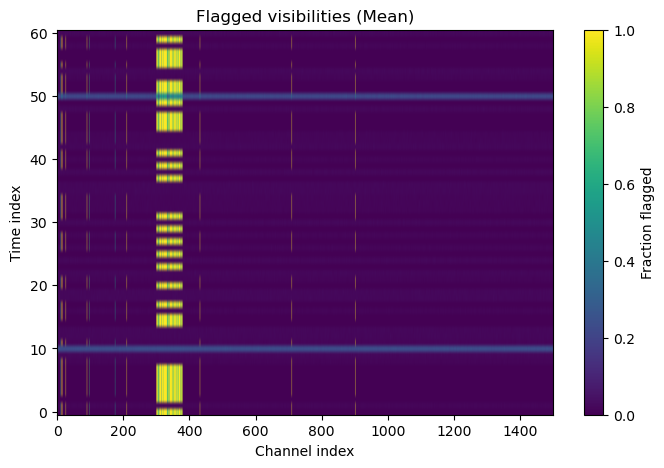

In [18]:
plot_flag_map(flags_stat, mode='mean')

In [19]:
calculate_rfi_metrics(predicted_mask=flags_stat, true_mask=true_mask)

{'Precision': np.float64(0.8005803440385302),
 'Recall': np.float64(0.548912610322494),
 'F1-Score': np.float64(0.6512796454386024),
 'TP': np.int64(6281106),
 'FP': np.int64(1564585),
 'FN': np.int64(5161710)}

## 3. Flaggin por variación de amplitud

In [20]:
from modules.flagging import amplitude_variation_flagging

u = uvw_lambda[...,0]
v = uvw_lambda[...,1]

flags_amp = amplitude_variation_flagging(V_corrupted, u, v)

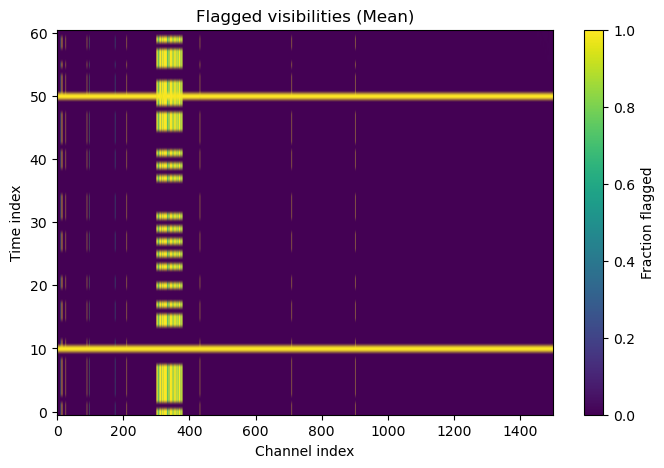

In [21]:
from modules.plots import plot_flag_map

plot_flag_map(flags_amp, mode='mean')

In [22]:
calculate_rfi_metrics(predicted_mask=flags_amp, true_mask=true_mask)

{'Precision': np.float64(0.9997426367129323),
 'Recall': np.float64(0.9556241225935993),
 'F1-Score': np.float64(0.977185661442901),
 'TP': np.int64(10935031),
 'FP': np.int64(2815),
 'FN': np.int64(507785)}

## 4. Flagging por coherencia de Fase

In [23]:
from modules.flagging import phase_coherence_flagging

flags_coh = phase_coherence_flagging(V_corrupted, w=8)

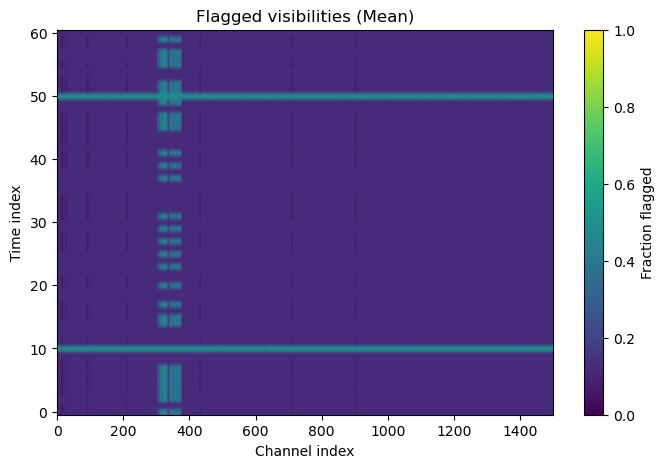

In [24]:
from modules.plots import plot_flag_map

plot_flag_map(flags_coh, mode='mean')

In [25]:
from modules.flagging import calculate_rfi_metrics

calculate_rfi_metrics(predicted_mask=flags_coh, true_mask=true_mask)

{'Precision': np.float64(0.1825433559656238),
 'Recall': np.float64(0.4001506272581854),
 'F1-Score': np.float64(0.2507142359264846),
 'TP': np.int64(4578850),
 'FP': np.int64(20504780),
 'FN': np.int64(6863966)}